In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
import datetime

import torch

DATA_PATH = "E:/ML/UBC/ColorectalHist"
print(DATA_PATH)


E:/ML/UBC/ColorectalHist


In [2]:
from sklearn.metrics import balanced_accuracy_score
from torchmetrics import Accuracy, Recall
from utils import BalancedAccuracy

y_true = np.array([0,0,1,2,2,2,2,2,2,3,3,3,3,4,4,4,4])
y_true = np.random.randint(0,5,100)
y_pred = np.array([0,0,1,2,2,2,2,2,2,3,3,3,3,1,1,4,1])
y_pred = np.random.randint(0,5,100)
print(balanced_accuracy_score(y_true, y_pred))


accMetric = Accuracy(task="multiclass", num_classes=5, average="macro")
print(accMetric(torch.Tensor(y_pred), torch.Tensor(y_true)).numpy())

recMetric = Recall(task="multiclass", num_classes=5, average="macro")
print(recMetric(torch.Tensor(y_pred), torch.Tensor(y_true)).numpy())

balAcc = BalancedAccuracy(5)
print(balAcc(torch.Tensor(y_pred), torch.Tensor(y_true)).numpy())

0.2345228301110654
0.23452282
0.23452282
0.23452285


c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchaudio\backend\utils.py:74: UserWarning: No audio backend is available.
  warnings.warn("No audio backend is available.")


In [9]:
sel = torch.arange(0,5,1)>2
torch.arange(0,5,1)[sel]

tensor([3, 4])

In [2]:
import timm
timm.list_models("*convnext*")

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['convnext_atto',
 'convnext_atto_ols',
 'convnext_base',
 'convnext_femto',
 'convnext_femto_ols',
 'convnext_large',
 'convnext_large_mlp',
 'convnext_nano',
 'convnext_nano_ols',
 'convnext_pico',
 'convnext_pico_ols',
 'convnext_small',
 'convnext_tiny',
 'convnext_tiny_hnf',
 'convnext_xlarge',
 'convnext_xxlarge',
 'convnextv2_atto',
 'convnextv2_base',
 'convnextv2_femto',
 'convnextv2_huge',
 'convnextv2_large',
 'convnextv2_nano',
 'convnextv2_pico',
 'convnextv2_small',
 'convnextv2_tiny']

In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Dataset

In [3]:
from sklearn.preprocessing import LabelEncoder

uniqueLabels = ["Tumor", "Stroma", "Complex", "Lympho", "Debris", "Mucosa", "Adipose", "Empty"]

enc = LabelEncoder()
enc.fit(uniqueLabels)
print(enc.classes_)
enc.transform(["Stroma"])

['Adipose' 'Complex' 'Debris' 'Empty' 'Lympho' 'Mucosa' 'Stroma' 'Tumor']


array([6])

In [4]:
allFiles = []
stopLoop = False
for root, dirs, files in os.walk(DATA_PATH, "Kather_texture_2016_image_tiles_5000", "01_TUMOR"):
    for f in files:
        if f.endswith(".tif"):
            allFiles.append(os.path.join(root, f))
    
len(allFiles)

5010

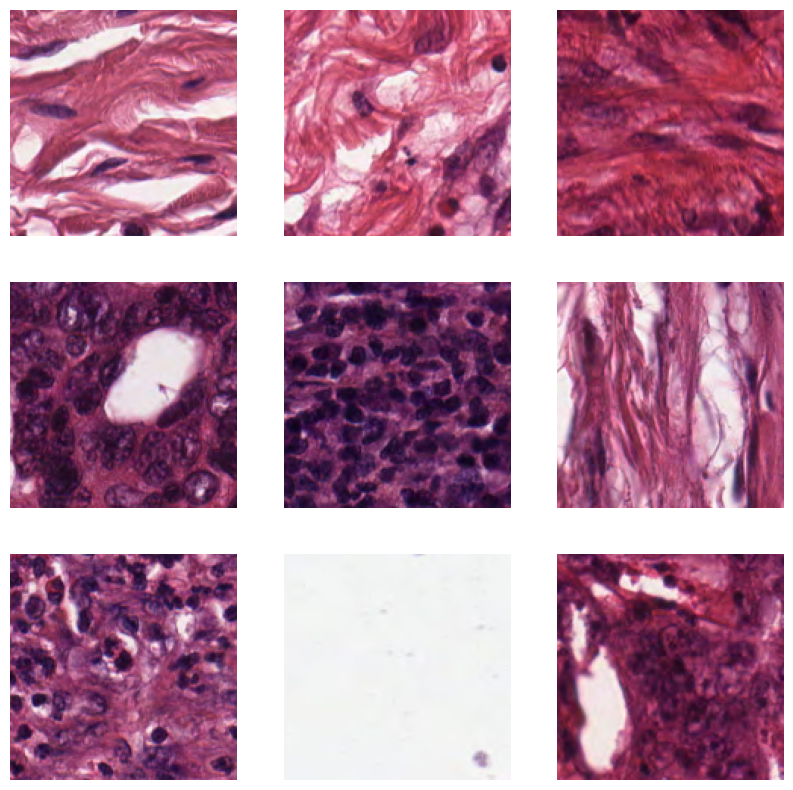

In [5]:

IMG_SIZE = (150, 150)
eps=1e-12

def readImage(path, skipResize=False):
    with Image.open(path) as data:
        
        w, h = data.width, data.height
        # centerWindow = data[w//4:3*w//4, h//4:3*h//4]
        # medValue = np.median(data)

        #Center crop
        if w>h:
            diff = w-h
            data = data[diff//2:diff//2+h, :]
        if h>w:
            diff = h-w
            data = data[:, diff//2:diff//2+w]

        # data = data - np.min(data)
        # data = data * 1.0/(np.max(data)+eps)

        w, h = data.width, data.height

        # resize
        if not skipResize:
            if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
                data = np.array(data.resize(IMG_SIZE))
        
        return np.array(data).astype(np.float32)/255.0



plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(readImage(filePath))
    _ = plt.axis("off")
# plt.colorbar()

In [6]:
data={}
paths=[]
allImages=[]
labels=[]

for i,label in enumerate(tqdm(uniqueLabels)):
    imData = []
    for root, dirs, files in os.walk(os.path.join(DATA_PATH, "Kather_texture_2016_image_tiles_5000", "0"+str(i+1)+"_"+label.upper())):
        for f in files:
            if f.endswith(".tif"):
                x = readImage(os.path.join(root, f))
                imData.append(x)
                allImages.append(x)
                encLabel=enc.transform([label.capitalize()])[0]
                # oheLabel = np.zeros(len(enc.classes_))
                # oheLabel[encLabel] = 1
                labels.append(encLabel.astype(np.int64))
                paths.append(os.path.join(root, f))
    data[label] = np.array(imData)

len(paths)

100%|██████████| 8/8 [00:03<00:00,  2.10it/s]


5000

'E:/ML/UBC/ColorectalHist\\Kather_texture_2016_image_tiles_5000\\01_TUMOR\\12F08_CRC-Prim-HE-02_007b.tif_Row_301_Col_1.tif'

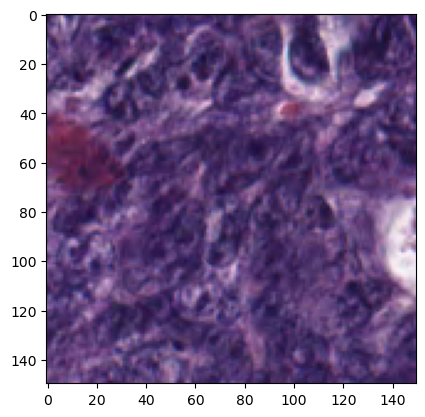

In [7]:
plt.imshow(data["Tumor"][100,:,:,:])
paths[100]
# labels[100]

In [8]:
TRAIN_TEST_SPLIT = 0.7

from sklearn.model_selection import train_test_split

allImages = np.array(allImages)
print(allImages.shape)
labels = np.array(labels).astype(np.int64)
print(labels.shape)


X_train, X_val, y_train, y_val = train_test_split( allImages, labels, test_size=1-TRAIN_TEST_SPLIT, random_state=42)
print(X_train.shape, X_val.shape)
print(y_train.dtype)

(5000, 150, 150, 3)
(5000,)
(3499, 150, 150, 3) (1501, 150, 150, 3)
int64


In [9]:
BATCH_SIZE = 32

dataset = torch.utils.data.TensorDataset(torch.Tensor(np.array(X_train)), torch.tensor(y_train, dtype=torch.int64))
datasetVal = torch.utils.data.TensorDataset(torch.Tensor(np.array(X_val)), torch.tensor(y_val, dtype=torch.int64))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
for X, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {X.shape} {X.dtype}")
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    # print(targets)
    break

Shape of X: torch.Size([32, 150, 150, 3]) torch.float32
Shape of target: torch.Size([32]) torch.int64


tensor(4)


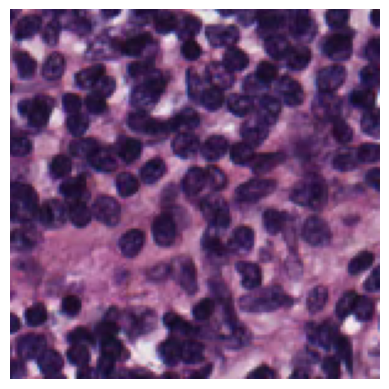

In [11]:
idx=5
print(targets[idx])
# plt.figure(figsize=(12,12))
plt.imshow(X[idx,:,:,:])
_=plt.axis("off")

## Pytorch Model

In [12]:
from torch import nn
import torchinfo
from torch import nn
import torch
from modelZoo.models import Res2DModel, ResNet2DModel

Dropout=0.1
HIDDEN_DIM=256
K=8

    
model = ResNet2DModel(len(enc.classes_), inputDim=IMG_SIZE[0], channels=3, name="Res2DModelColorectal_K_{}".format(K), K=K, Dropout=Dropout, HiddenDim=HIDDEN_DIM, useGAP=True)


from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)

model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                   Output Shape              Param #
ResNet2DModel                            [32, 8]                   --
├─convBlockResDown: 1-1                  [32, 16, 75, 75]          --
│    └─BatchNorm2d: 2-1                  [32, 3, 150, 150]         6
│    └─LeakyReLU: 2-2                    [32, 3, 150, 150]         --
│    └─Conv2d: 2-3                       [32, 3, 150, 150]         84
│    └─Dropout2d: 2-4                    [32, 3, 150, 150]         --
│    └─BatchNorm2d: 2-5                  [32, 3, 150, 150]         6
│    └─LeakyReLU: 2-6                    [32, 3, 150, 150]         --
│    └─Conv2d: 2-7                       [32, 16, 75, 75]          448
│    └─Dropout2d: 2-8                    [32, 16, 75, 75]          --
│    └─Conv2d: 2-9                       [32, 16, 75, 75]          272
│    └─BatchNorm2d: 2-10                 [32, 3, 150, 150]         6
│    └─LeakyReLU: 2-11                   [32, 3, 150, 150]         --
│    └─Conv2d: 2

In [13]:
# model_graph.visual_graph

In [14]:
loadExistingModel=False

if loadExistingModel:
    # model = simpleUnet(K=4)
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=8e-4)

    checkpoint = torch.load(os.path.join("./", "ConvLSTMModelDaily2_epoch_999.pt"), map_location=device)
    # startEpoch=136
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)
    startEpoch = checkpoint['epoch']
    # loss = checkpoint['loss']
    model.train()
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), 5e-4)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.998)

In [15]:
from torcheval import metrics
from torch.utils.tensorboard import SummaryWriter
from torchmetrics import AUROC, Accuracy


LOG_INTERVAL=5
epochs = 100
EARLY_STOPPING_PATIENCE=10
saveModel=False


log_dir = "./logs/"+model.name+"/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = SummaryWriter(log_dir)

# Instantiate an optimizer .
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Instantiate a loss function.
lossFn = torch.nn.CrossEntropyLoss()


accMetric = Accuracy(task="multiclass", num_classes=len(enc.classes_), average="micro").to(device)
aurocMetric = AUROC(task="multiclass", num_classes=len(enc.classes_)).to(device)
# f1Metric = tf.keras.metrics.F1Score(threshold=0.5, average="micro")

accMetricVal = Accuracy(task="multiclass", num_classes=len(enc.classes_), average="micro").to(device)


def train(dataloader, model, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X = X.movedim(-1,1)
        X, y = X.to(device), y.to(device)
        pred = model(X)
        # predictions = torch.cat(pred, axis=-1)
        
        loss = lossFn(pred, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        accMetric.update(pred, y)
        aurocMetric.update(pred, y)
        
        if batch % LOG_INTERVAL == 0:
            loss = loss.item()
            print("loss: {:>5f}, acc: {:.4f}, AUROC: {:.4f}  [{:>5d}/{:>5d}]".format(loss, accMetric.compute(), aurocMetric.compute(), batch*BATCH_SIZE, size))
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Acc", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("AUROC", aurocMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()



def validate(dataloader, model, epoch):
    print("Start Validation...")
    model.eval()
    loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.movedim(-1,1)
        X, y = X.to(device), y.to(device)
        pred = model(X)
        lossAdd = lossFn(pred, y)
        loss += lossAdd.detach().cpu().numpy()
        accMetricVal.update(pred, y)
        
    lossVal = loss.item()/(batch+1)
    print("Weighted Avg Cross Entropy: {:>7f}".format(lossVal))
    print("Accuracy: {:>7f}".format(accMetricVal.compute()))
    summary_writer.add_scalar("Val BCE", lossVal, epoch)
    summary_writer.add_scalar("Val Accuracy", accMetricVal.compute(), epoch)
    summary_writer.flush()
    return accMetricVal.compute()


bestValAcc=0.0
bestEpoch=0


for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, optimizer, t)
    accMetric.reset()
    aurocMetric.reset()

    avgAccVal = validate(valLoader, model, t)
    accMetricVal.reset()
    
    if saveModel:
        model_scripted = torch.jit.script(model) # Export to TorchScript
        fileName = "{}_epoch{}_CE{:.4f}.pt".format(model.name, t, avgAccVal)
        model_scripted.save(os.path.join(DATA_PATH, fileName))
    
    #Early stopping
    if avgAccVal > bestValAcc:
        bestValAcc = avgAccVal
        bestEpoch = t
    if t - bestEpoch >= EARLY_STOPPING_PATIENCE:
        print("Early stopping")
        break
print("Done!")
print(bestValAcc)

c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchaudio\backend\utils.py:74: UserWarning: No audio backend is available.
  warnings.warn("No audio backend is available.")


Epoch 1
-------------------------------


c:\Users\Manuel\anaconda3\envs\torch\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)  # noqa: B028


loss: 2.083200, acc: 0.0625, AUROC: 0.4072  [    0/ 3499]
loss: 2.094541, acc: 0.1354, AUROC: 0.4900  [  160/ 3499]
loss: 1.837194, acc: 0.1676, AUROC: 0.5720  [  320/ 3499]
loss: 1.759844, acc: 0.1973, AUROC: 0.6353  [  480/ 3499]
loss: 1.390605, acc: 0.2202, AUROC: 0.6737  [  640/ 3499]
loss: 1.616845, acc: 0.2308, AUROC: 0.6965  [  800/ 3499]
loss: 1.650907, acc: 0.2460, AUROC: 0.7072  [  960/ 3499]
loss: 1.500432, acc: 0.2587, AUROC: 0.7203  [ 1120/ 3499]
loss: 1.573012, acc: 0.2660, AUROC: 0.7296  [ 1280/ 3499]
loss: 1.521891, acc: 0.2711, AUROC: 0.7415  [ 1440/ 3499]
loss: 1.517867, acc: 0.2806, AUROC: 0.7484  [ 1600/ 3499]
loss: 1.567173, acc: 0.2885, AUROC: 0.7549  [ 1760/ 3499]
loss: 1.560865, acc: 0.2951, AUROC: 0.7602  [ 1920/ 3499]
loss: 1.403581, acc: 0.2992, AUROC: 0.7649  [ 2080/ 3499]
loss: 1.393099, acc: 0.3028, AUROC: 0.7707  [ 2240/ 3499]
loss: 1.360775, acc: 0.3072, AUROC: 0.7746  [ 2400/ 3499]
loss: 1.541282, acc: 0.3129, AUROC: 0.7775  [ 2560/ 3499]
loss: 1.576442

In [16]:
# torch.save({
#         'epoch': t,
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         # 'scheduler_state_dict': scheduler.state_dict(),
#         # 'loss': loss,
#         }, os.path.join("./", model.name+"_epoch_{}.pt".format(t)))

In [17]:
# torch.save(model.state_dict, os.path.join(DATA_PATH, "convModel.pt"))

# model_scripted = torch.jit.script(model) # Export to TorchScript
# model_scripted.save('model_scripted.pt') # Save